169001437/169001437 [==============================] - 3s 0us/step
Epoch 1/30
782/782 [==============================] - 97s 121ms/step - loss: 4.0994 - accuracy: 0.0106 - val_loss: 3.1652 - val_accuracy: 0.0054
Epoch 2/30
782/782 [==============================] - 104s 132ms/step - loss: 3.2670 - accuracy: 0.0111 - val_loss: 3.1876 - val_accuracy: 0.0050
Epoch 3/30
782/782 [==============================] - 97s 124ms/step - loss: 2.9121 - accuracy: 0.0112 - val_loss: 2.7532 - val_accuracy: 0.0089
Epoch 4/30
782/782 [==============================] - 106s 135ms/step - loss: 2.7057 - accuracy: 0.0108 - val_loss: 2.4281 - val_accuracy: 0.0076
Epoch 5/30
782/782 [==============================] - 100s 127ms/step - loss: 2.5669 - accuracy: 0.0104 - val_loss: 2.3439 - val_accuracy: 0.0080
Epoch 6/30
782/782 [==============================] - 104s 133ms/step - loss: 2.4611 - accuracy: 0.0108 - val_loss: 2.3542 - val_accuracy: 0.0064
Epoch 7/30
782/782 [==============================] - 108s 

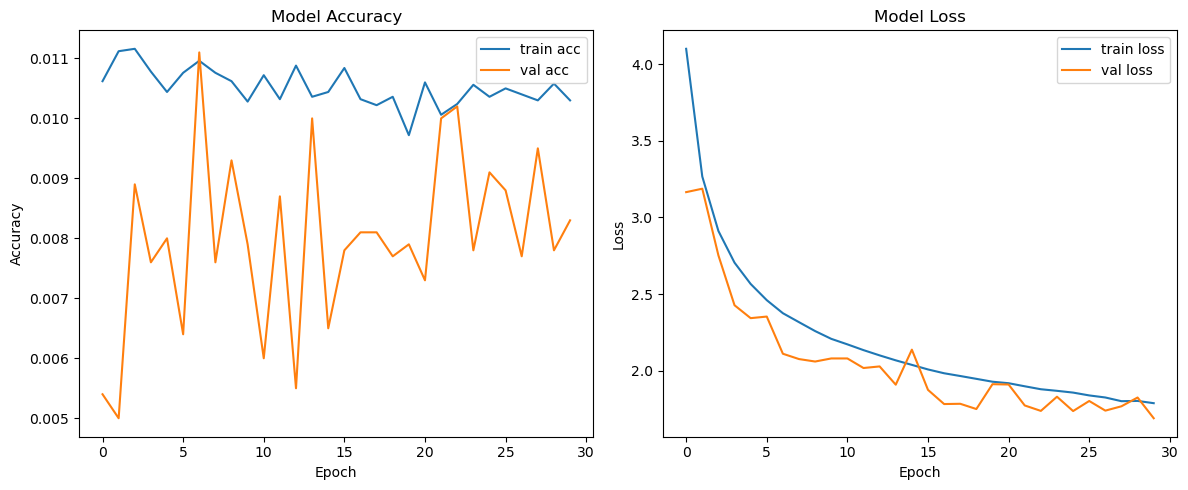

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train)

# Define CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(100, activation='softmax')  # CIFAR-100 has 100 classes
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    epochs=30,
                    validation_data=(x_test, y_test))

# Plot training & validation accuracy/loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
